Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 50ms/step - bbox_loss: 0.1044 - class_loss: 1.4095 - loss: 1.5141
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 88s 53ms/step - bbox_loss: 0.0917 - class_loss: 1.0259 - loss: 1.1175
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 144s 55ms/step - bbox_loss: 0.0878 - class_loss: 0.8861 - loss: 0.9740


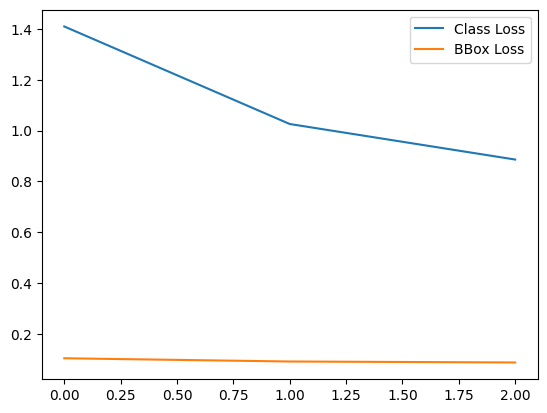

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

(train_images, train_labels), _ = keras.datasets.cifar10.load_data()
train_images = train_images / 255.0

inputs = keras.Input(shape=(32,32,3))
x = layers.Conv2D(32,3,activation='relu')(inputs)
x = layers.MaxPooling2D()(x)
x = layers.Conv2D(64,3,activation='relu')(x)
x = layers.Flatten()(x)
x = layers.Dense(64,activation='relu')(x)

bbox_output = layers.Dense(4, name="bbox")(x)
class_output = layers.Dense(10, activation='softmax', name="class")(x)

model = keras.Model(inputs=inputs, outputs=[bbox_output, class_output])

model.compile(optimizer='adam',
              loss={'bbox':'mse','class':'sparse_categorical_crossentropy'})

dummy_bbox = np.random.rand(len(train_images),4)

history = model.fit(train_images, {"bbox":dummy_bbox, "class":train_labels}, epochs=3)

plt.plot(history.history['class_loss'], label='Class Loss')
plt.plot(history.history['bbox_loss'], label='BBox Loss')
plt.legend()
plt.show()